Lab 2: Bài thực hành trình bày dữ liệu

Phần 1: Thống kê dữ liệu

1. Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nạp dữ liệu
df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')
cau1 = df.sort_values(by='DH1')
print(cau1[['STT', 'DH1']].head())

    STT   DH1
53   54  1.00
43   44  1.25
72   73  1.50
5     6  1.50
87   88  1.75


2. Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính

In [5]:
cau2 = df.sort_values(by=['GT', 'DH2'])
print(cau2.head())

    STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...  TBM1  TBM2  TBM3  \
95   96  8.6  6.9  7.4  8.8  7.6  5.8  7.3  5.7  8.9  ...  7.43  7.42  7.04   
25   26  3.6  5.8  6.9  6.1  5.5  7.2  5.5  4.3  4.2  ...  5.40  5.20  5.02   
24   25  2.4  4.1  3.6  5.5  5.9  5.6  4.9  4.2  3.3  ...  4.45  4.88  5.31   
46   47  6.7  6.8  6.4  5.9  5.6  6.4  8.0  6.8  6.6  ...  6.49  6.51  6.95   
13   14  4.9  5.4  5.0  5.0  5.8  7.0  4.2  5.8  4.5  ...  5.38  5.51  5.69   

    XL1  XL2  XL3   US_TBM1   US_TBM2   US_TBM3  KQXT  
95    K    K    K  3.356436  2.912621  3.025522     0  
25   TB   TB   TB  1.346535  0.757282  1.150812     0  
24    Y    Y   TB  0.405941  0.446602  1.419954     0  
46   TB    K    K  2.425743  2.029126  2.941995     0  
13   TB   TB   TB  1.326733  1.058252  1.772622     0  

[5 rows x 67 columns]


3. Pivot-table thống kê DH1 theo KT

In [10]:
stats = ['count', 'sum', 'mean', 'median', 'min', 'max', 'std', 
         lambda x: x.quantile(0.25), lambda x: x.quantile(0.5), lambda x: x.quantile(0.75)]
cau3 = df.groupby('KT')['DH1'].agg(stats)
print(cau3)

    count     sum      mean  median   min   max       std  <lambda_0>  \
KT                                                                      
A      49  163.50  3.336735    3.25  1.00  6.50  1.274296      2.2500   
A1      6   17.50  2.916667    3.00  2.00  4.25  0.861201      2.1875   
B       9   29.50  3.277778    3.50  1.75  4.50  0.823905      3.2500   
C      14   79.25  5.660714    5.25  4.75  7.00  0.812209      5.0625   
D1     22   84.25  3.829545    3.75  1.25  6.75  1.370146      3.0000   

    <lambda_1>  <lambda_2>  
KT                          
A         3.25       4.250  
A1        3.00       3.250  
B         3.50       3.750  
C         5.25       6.375  
D1        3.75       4.875  


4. Pivot-table thống kê DH1 theo KT và KV

In [8]:
cau4 = df.groupby(['KT', 'KV'])['DH1'].agg(stats)
print(cau4)

        count    sum      mean  median   min   max       std  <lambda_0>  \
KT KV                                                                      
A  1       29  93.75  3.232759   3.250  1.00  6.50  1.369194      2.0000   
   2        9  31.75  3.527778   3.500  2.00  6.25  1.427653      2.2500   
   2NT     11  38.00  3.454545   3.500  2.00  4.75  0.913908      2.8750   
A1 1        2   4.75  2.375000   2.375  2.00  2.75  0.530330      2.1875   
   2NT      4  12.75  3.187500   3.250  2.00  4.25  0.921389      2.9375   
B  1        8  25.75  3.218750   3.375  1.75  4.50  0.860207      3.0000   
   2NT      1   3.75  3.750000   3.750  3.75  3.75       NaN      3.7500   
C  1        8  43.50  5.437500   5.250  4.75  7.00  0.728869      5.0000   
   2        2  11.50  5.750000   5.750  5.00  6.50  1.060660      5.3750   
   2NT      4  24.25  6.062500   6.000  5.25  7.00  0.943729      5.2500   
D1 1       13  46.75  3.596154   3.500  1.50  5.75  1.264658      2.7500   
   2        

5. Pivot-table thống kê DH1 theo KT, KV và DT

In [11]:
cau5 = df.groupby(['KT', 'KV', 'DT'])['DH1'].agg(stats)
print(cau5)

                 count    sum      mean  median   min   max       std  \
KT KV  DT                                                               
A  1   2.666667     29  93.75  3.232759   3.250  1.00  6.50  1.369194   
   2   2.666667      8  27.50  3.437500   3.000  2.00  6.25  1.498511   
       6.000000      1   4.25  4.250000   4.250  4.25  4.25       NaN   
   2NT 2.666667     11  38.00  3.454545   3.500  2.00  4.75  0.913908   
A1 1   2.666667      2   4.75  2.375000   2.375  2.00  2.75  0.530330   
   2NT 2.666667      4  12.75  3.187500   3.250  2.00  4.25  0.921389   
B  1   2.666667      8  25.75  3.218750   3.375  1.75  4.50  0.860207   
   2NT 2.666667      1   3.75  3.750000   3.750  3.75  3.75       NaN   
C  1   2.666667      8  43.50  5.437500   5.250  4.75  7.00  0.728869   
   2   2.666667      2  11.50  5.750000   5.750  5.00  6.50  1.060660   
   2NT 2.666667      4  24.25  6.062500   6.000  5.25  7.00  0.943729   
D1 1   1.000000      1   3.00  3.000000   3.000  3.

PHẦN 2: TRÌNH BÀY DỮ LIỆU

1. Trình bày biến GT

M    52
F    48
Name: GT, dtype: int64
M    0.52
F    0.48
Name: GT, dtype: float64


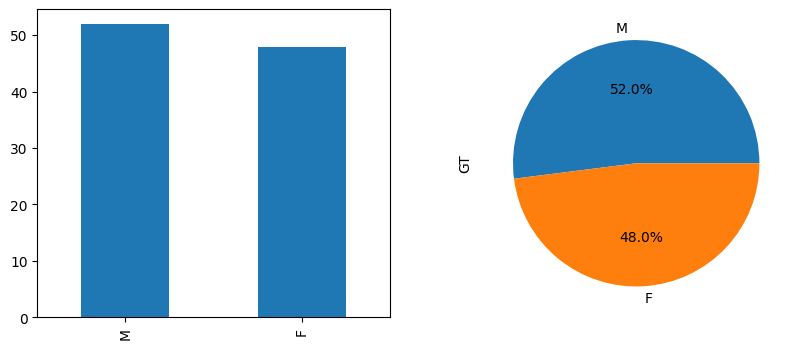

In [12]:
# Tần số và tần suất
print(df['GT'].value_counts())
print(df['GT'].value_counts(normalize=True))

# Biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df['GT'].value_counts().plot(kind='bar', ax=ax[0])
df['GT'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
plt.show()

2. Trình bày US_TBM1, US_TBM2, US_TBM3

Thống kê cho US_TBM1:
count    100.000000
mean       2.025941
std        0.968324
min        0.000000
25%        1.215347
50%        2.138614
75%        2.742574
max        4.000000
Name: US_TBM1, dtype: float64


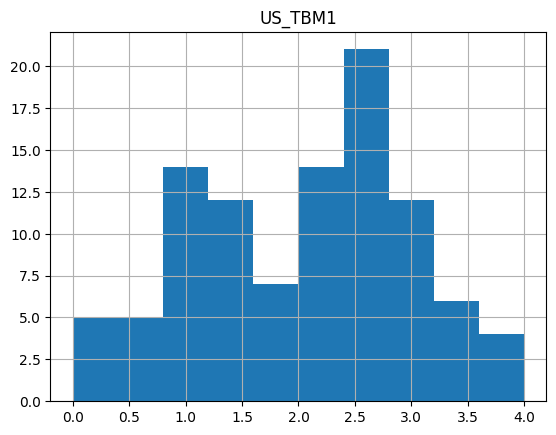

Thống kê cho US_TBM2:
count    100.000000
mean       1.921359
std        0.916640
min        0.000000
25%        1.104369
50%        1.990291
75%        2.730583
max        4.000000
Name: US_TBM2, dtype: float64


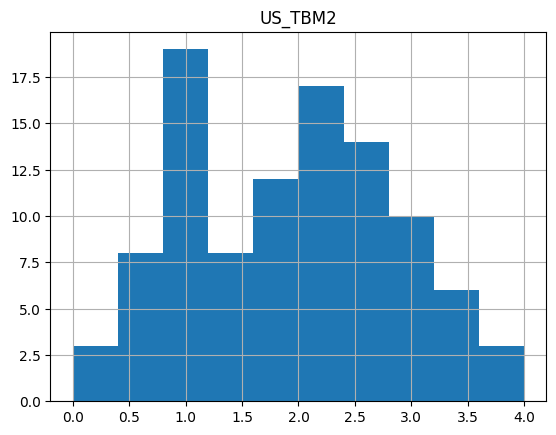

Thống kê cho US_TBM3:
count    100.000000
mean       2.381160
std        0.872736
min        0.000000
25%        1.737819
50%        2.436195
75%        3.018561
max        4.000000
Name: US_TBM3, dtype: float64


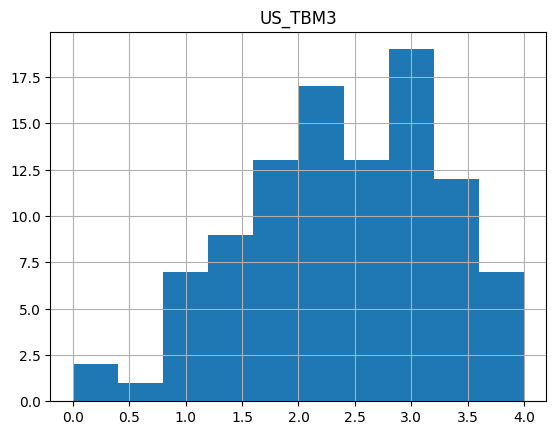

In [13]:
for col in ['US_TBM1', 'US_TBM2', 'US_TBM3']:
    print(f"Thống kê cho {col}:")
    print(df[col].describe())
    df[col].hist()
    plt.title(col)
    plt.show()

3. Trình bày biến DT với học sinh nam (GT='M')

In [14]:
print(df[df['GT'] == 'M']['DT'].value_counts())

2.666667    50
1.000000     1
6.000000     1
Name: DT, dtype: int64


4. Học sinh nam, dân tộc Kinh, điều kiện (DH1>=5, DH2>=4, DH3>=4

In [15]:
subset = df[(df['GT'] == 'M') & (df['DanToc'] == 'Kinh') & 
            (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)]
print(subset['KV'].value_counts())

Series([], Name: KV, dtype: int64)


5. DH1, DH2, DH3 >= 5.0 và thuộc khu vực 2NT

In [17]:
subset5 = df[(df['DH1'] >= 5.0) & (df['DH2'] >= 5.0) & (df['DH3'] >= 5.0) & (df['KV'] == '2NT')]
print(subset5)

    STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...  TBM1  TBM2  TBM3  \
23   24  5.3  6.3  5.7  6.9  5.9  7.5  6.6  5.1  6.4  ...  6.05  6.32   6.2   

    XL1  XL2  XL3   US_TBM1  US_TBM2  US_TBM3  KQXT  
23   TB   TB   TB  1.990099  1.84466  2.24594     1  

[1 rows x 67 columns]


PHẦN 3: TRỰC QUAN HÓA THEO NHÓM

1. Học sinh nữ (GT='F') trên XL1, XL2, XL3 (Unstacked)

<AxesSubplot: xlabel='variable', ylabel='count'>

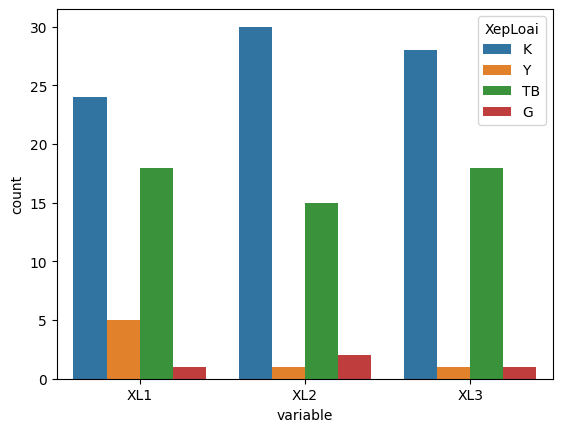

In [18]:
df_nu = df[df['GT'] == 'F'].melt(value_vars=['XL1', 'XL2', 'XL3'], value_name='XepLoai')
sns.countplot(data=df_nu, x='variable', hue='XepLoai')

PHẦN 4: TRỰC QUAN HÓA NÂNG CAO

2. Tạo biến phanloait1

In [20]:
# Sử dụng ordered=False để cho phép các nhãn trùng nhau
bins = [0, 5, 7, 8, 11]
labels = ['k', 'tb', 'k', 'g']

df['phanloait1'] = pd.cut(df['T1'], bins=bins, labels=labels, include_lowest=True, ordered=False)

# Kiểm tra lại kết quả
print(df['phanloait1'].value_counts())

k     44
tb    44
g     12
Name: phanloait1, dtype: int64


4 & 5. Biểu đồ đường và Drop-line

<AxesSubplot: ylabel='T1'>

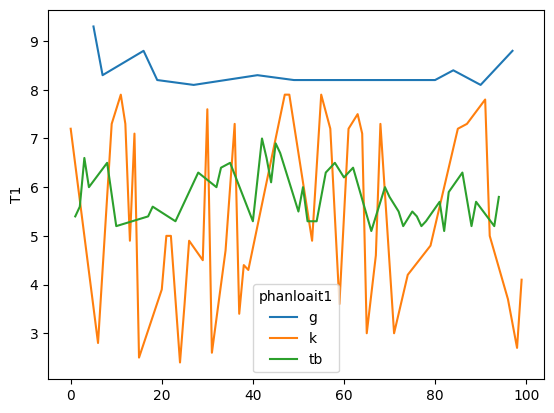

In [21]:
sns.lineplot(data=df, x=df.index, y='T1', hue='phanloait1')

PHẦN 5: MÔ TẢ VÀ PHÂN PHỐI

1. Khảo sát phân phối T1

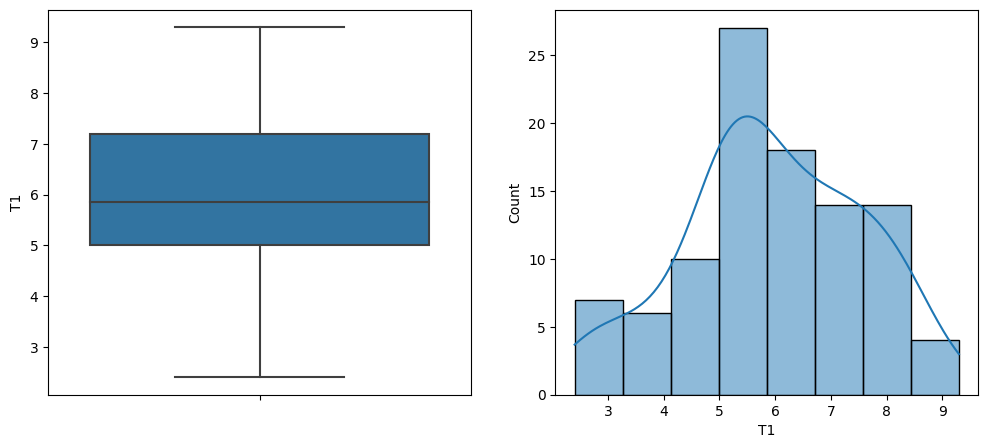

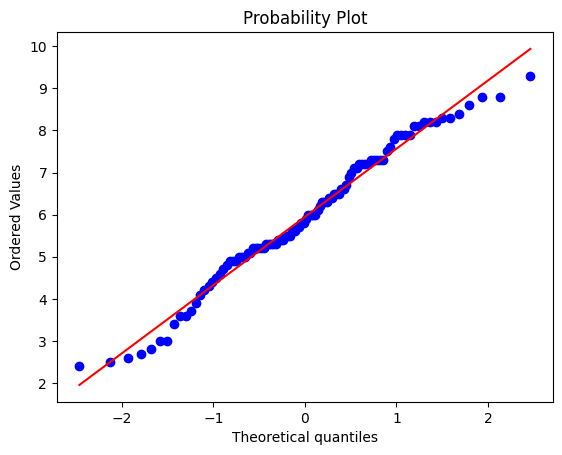

In [22]:
# Boxplot và Histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['T1'], ax=ax[0])
sns.histplot(df['T1'], kde=True, ax=ax[1])
plt.show()

# Kiểm chứng chuẩn (QQ-plot)
import scipy.stats as stats
stats.probplot(df['T1'], dist="norm", plot=plt)
plt.show()

3. Tương quan DH1 và T1

0.04925439216104145


<AxesSubplot: xlabel='T1', ylabel='DH1'>

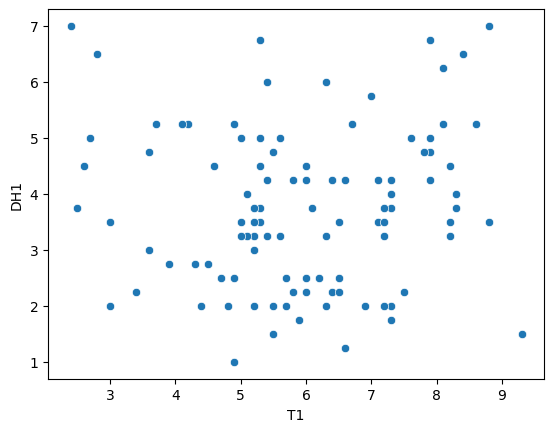

In [23]:
print(df['DH1'].corr(df['T1']))
sns.scatterplot(x='T1', y='DH1', data=df)